<a href="https://colab.research.google.com/github/aryan-327/IML-LAB/blob/main/exp_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Solution from equations:
{w1: 1 - b/2, w2: -1}

Chosen minimum norm solution:
Weight vector w = [ 0 -1]
Bias b = 2

Decision Boundary Equation:
w·x + b = 0
-x2 + 2 = 0
x2 = 2

Predictions:
Point [1 1] → f(x) = 1 → Predicted: 1
Point [2 1] → f(x) = 1 → Predicted: 1
Point [2 3] → f(x) = -1 → Predicted: -1
Point [3 3] → f(x) = -1 → Predicted: -1


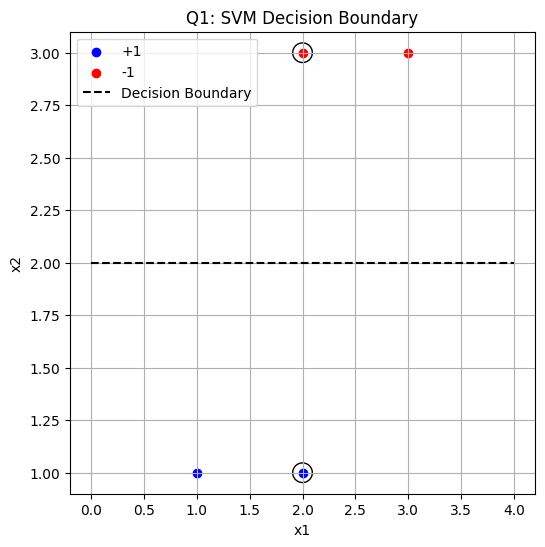

In [ ]:

"""
Q1: Apply Hard-Margin SVM and find:

Points:
A (1,1)  →  +1
B (2,1)  →  +1
C (2,3)  →  -1
D (3,3)  →  -1

Given Support Vectors:
B (2,1) and C (2,3)

We use hard-margin SVM conditions:

For support vectors:
    yi (w · xi + b) = 1

Goal:
1) Find weight vector w
2) Find bias b
3) Write decision boundary
4) Predict labels
"""

import sympy as sp
import numpy as np

# -------------------------------------------------
# Step 1: Define symbolic variables for w and b
# -------------------------------------------------

w1, w2, b = sp.symbols('w1 w2 b')

# Support vectors
B = (2, 1)   # +1
C = (2, 3)   # -1

# -------------------------------------------------
# Step 2: Apply SVM support vector conditions
# yi (w · xi + b) = 1
# -------------------------------------------------

# For B (y = +1)
eq1 = 2*w1 + 1*w2 + b - 1

# For C (y = -1)
eq2 = 2*w1 + 3*w2 + b + 1   # equals 0 after rearranging

# -------------------------------------------------
# Step 3: Solve equations
# -------------------------------------------------

solution = sp.solve((eq1, eq2), (w1, w2, b))

print("Solution from equations:")
print(solution)

# From manual reasoning (minimum norm solution):
w = np.array([0, -1])
b_val = 2

print("\nChosen minimum norm solution:")
print("Weight vector w =", w)
print("Bias b =", b_val)

# -------------------------------------------------
# Step 4: Decision Boundary
# -------------------------------------------------

print("\nDecision Boundary Equation:")
print("w·x + b = 0")
print("-x2 + 2 = 0")
print("x2 = 2")

# -------------------------------------------------
# Step 5: Predict labels
# -------------------------------------------------

points = np.array([
    [1,1],   # A
    [2,1],   # B
    [2,3],   # C
    [3,3]    # D
])

labels_true = np.array([1,1,-1,-1])

print("\nPredictions:")

for i in range(len(points)):
    fx = np.dot(w, points[i]) + b_val
    prediction = 1 if fx > 0 else -1
    print(f"Point {points[i]} → f(x) = {fx} → Predicted: {prediction}")


import matplotlib.pyplot as plt

# ==========================================================
# Q1 PLOT (2D Case)
# ==========================================================

plt.figure(figsize=(6,6))

# Points
A = np.array([1,1])
B = np.array([2,1])
C = np.array([2,3])
D = np.array([3,3])

# Plot points
plt.scatter(A[0], A[1], color='blue', label='+1')
plt.scatter(B[0], B[1], color='blue')
plt.scatter(C[0], C[1], color='red', label='-1')
plt.scatter(D[0], D[1], color='red')

# Highlight Support Vectors
plt.scatter(B[0], B[1], s=200, facecolors='none', edgecolors='black')
plt.scatter(C[0], C[1], s=200, facecolors='none', edgecolors='black')

# Decision boundary: x2 = 2
x_vals = np.linspace(0,4,100)
y_vals = np.ones_like(x_vals) * 2
plt.plot(x_vals, y_vals, 'k--', label='Decision Boundary')

plt.title("Q1: SVM Decision Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()
plt.show()

Step 1: Dot Products (xi · x)

x1 · x = 0.30000000000000004
x2 · x = -0.2
x3 · x = 0.6000000000000001

Step 2: Multiply by yi and alpha_i

Contribution from SV1: 0.30000000000000004
Contribution from SV2: 0.2
Contribution from SV3: -0.6000000000000001

Step 3: Compute decision function
f(x) = -0.10000000000000009

Step 4: Predicted Class
Predicted class label: -1


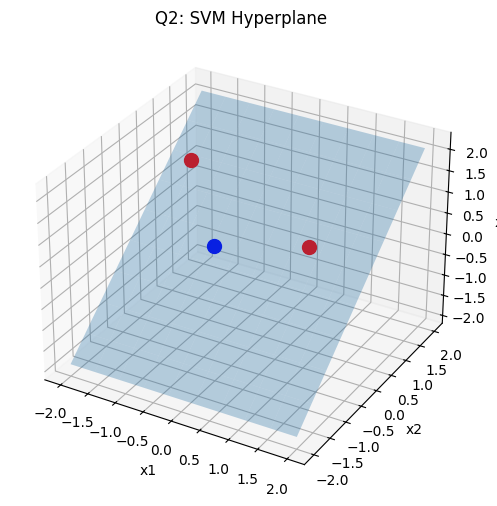

In [ ]:
"""
Q2: Hard-Margin Linear SVM Prediction

Given:
- Multipliers (alphas) = [1, 1, 1]

Support Vectors (xi) and Labels (yi):

    x1 = (0, -1, 1)   → y1 = +1
    x2 = (0,  2, -1)  → y2 = -1
    x3 = (-1, 0,  2)  → y3 = -1

Input feature vector:
    x = (0.2, 0.1, 0.4)

Bias term:
    b = 0

We compute the SVM decision function:

    f(x) = Σ alpha_i * y_i * (xi · x)

Since alpha_i = 1:

    f(x) = Σ y_i * (xi · x)

Decision rule:
    if f(x) > 0 → +1
    if f(x) < 0 → -1
"""

import numpy as np

# -------------------------------------------------
# Step 1: Define Support Vectors and Labels
# -------------------------------------------------

support_vectors = np.array([
    [0, -1, 1],    # x1
    [0,  2, -1],   # x2
    [-1, 0, 2]     # x3
])

labels = np.array([1, -1, -1])   # y1, y2, y3

# Input vector
x = np.array([0.2, 0.1, 0.4])

# All alphas = 1
alphas = np.array([1, 1, 1])

# -------------------------------------------------
# Step 2: Compute dot products (xi · x)
# -------------------------------------------------

print("Step 1: Dot Products (xi · x)\n")

dot_products = []

for i in range(len(support_vectors)):
    dot = np.dot(support_vectors[i], x)
    dot_products.append(dot)
    print(f"x{i+1} · x = {dot}")

# -------------------------------------------------
# Step 3: Multiply by yi and alpha_i
# -------------------------------------------------

print("\nStep 2: Multiply by yi and alpha_i\n")

contributions = []

for i in range(len(dot_products)):
    contribution = alphas[i] * labels[i] * dot_products[i]
    contributions.append(contribution)
    print(f"Contribution from SV{i+1}: {contribution}")

# -------------------------------------------------
# Step 4: Sum Contributions
# -------------------------------------------------

f_x = sum(contributions)

print("\nStep 3: Compute decision function")
print(f"f(x) = {f_x}")

# -------------------------------------------------
# Step 5: Determine Predicted Class
# -------------------------------------------------

print("\nStep 4: Predicted Class")

if f_x > 0:
    prediction = +1
elif f_x < 0:
    prediction = -1
else:
    prediction = +1   # convention for boundary case

print(f"Predicted class label: {prediction}")


from mpl_toolkits.mplot3d import Axes3D

# Weight and bias computed earlier
w2 = np.array([0, -0.5, 0.5])
b2 = -0.05

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

# Points
points_q2 = np.array([
    [0,-1,1],
    [0,2,-1],
    [-1,0,2]
])
labels_q2 = [1,-1,-1]

for i in range(len(points_q2)):
    color = 'blue' if labels_q2[i]==1 else 'red'
    ax.scatter(points_q2[i][0], points_q2[i][1], points_q2[i][2], color=color, s=100)

# Create plane
xx, yy = np.meshgrid(np.linspace(-2,2,10), np.linspace(-2,2,10))
zz = (-w2[0]*xx - w2[1]*yy - b2)/w2[2]

ax.plot_surface(xx, yy, zz, alpha=0.3)

ax.set_title("Q2: SVM Hyperplane")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")

plt.show()

Step 1: Compute dot products (xi · x)

x1 · x = 1.0
x2 · x = 1.5
x3 · x = -0.5

Step 2: Multiply by yi and alpha_i

Contribution from SV1: 1.0
Contribution from SV2: -1.5
Contribution from SV3: 0.5

Step 3: Sum all contributions
f(x) = 0.0

Step 4: Determine predicted class
Predicted class label: 1


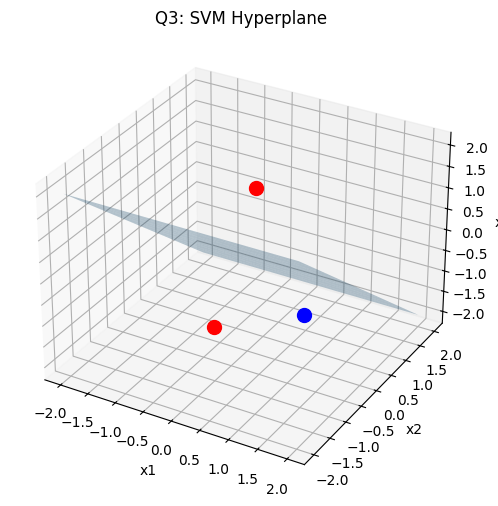

In [ ]:
"""
Q3: Hard-Margin Linear SVM Decision Function

Given:
- All alpha_i = 1
- Support vectors (xi) with labels (yi):

    x1 = (1, 0, -1)   → y1 = +1
    x2 = (-1, 2, 0)   → y2 = -1
    x3 = (0, -1, -1)  → y3 = -1

- New input:
    x = (0.5, 1, -0.5)

- Bias term b = 0

We compute the SVM decision function:

    f(x) = Σ alpha_i * y_i * (xi · x)

Since alpha_i = 1 for all support vectors:

    f(x) = Σ y_i * (xi · x)

We then determine the predicted class:
    if f(x) > 0  → +1
    if f(x) < 0  → -1
    if f(x) = 0  → on decision boundary (often classified as +1)
"""

import numpy as np

# ----------------------------
# Step 1: Define support vectors and labels
# ----------------------------

support_vectors = np.array([
    [1, 0, -1],     # x1
    [-1, 2, 0],     # x2
    [0, -1, -1]     # x3
])

labels = np.array([1, -1, -1])   # y1, y2, y3

# New input point
x = np.array([0.5, 1, -0.5])

# All alpha_i = 1
alphas = np.array([1, 1, 1])

# ----------------------------
# Step 2: Compute dot products (xi · x)
# ----------------------------

print("Step 1: Compute dot products (xi · x)\n")

dot_products = []

for i in range(len(support_vectors)):
    dot = np.dot(support_vectors[i], x)
    dot_products.append(dot)
    print(f"x{i+1} · x = {dot}")

# ----------------------------
# Step 3: Multiply by yi and alpha_i
# ----------------------------

print("\nStep 2: Multiply by yi and alpha_i\n")

contributions = []

for i in range(len(dot_products)):
    contribution = alphas[i] * labels[i] * dot_products[i]
    contributions.append(contribution)
    print(f"Contribution from SV{i+1}: {contribution}")

# ----------------------------
# Step 4: Sum contributions
# ----------------------------

f_x = sum(contributions)

print("\nStep 3: Sum all contributions")
print(f"f(x) = {f_x}")

# ----------------------------
# Step 5: Determine predicted class
# ----------------------------

print("\nStep 4: Determine predicted class")

if f_x > 0:
    prediction = +1
elif f_x < 0:
    prediction = -1
else:
    prediction = +1   # convention when on boundary

print(f"Predicted class label: {prediction}")


# Weight and bias computed earlier
w3 = np.array([0, -0.5, -0.5])
b3 = 0

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

points_q3 = np.array([
    [1,0,-1],
    [-1,2,0],
    [0,-1,-1]
])
labels_q3 = [1,-1,-1]

for i in range(len(points_q3)):
    color = 'blue' if labels_q3[i]==1 else 'red'
    ax.scatter(points_q3[i][0], points_q3[i][1], points_q3[i][2], color=color, s=100)

# Create plane
xx, yy = np.meshgrid(np.linspace(-2,2,10), np.linspace(-2,2,10))
zz = (-w3[0]*xx - w3[1]*yy - b3)/w3[2]

ax.plot_surface(xx, yy, zz, alpha=0.3)

ax.set_title("Q3: SVM Hyperplane")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")

plt.show()